# Signals and systems: delta, impulse response, filters, and time-stretch

A linear time-invariant (LTI) system is completely described by one signal: its **impulse response**
$h(t)$, the output when the input is a Dirac delta $\delta(t)$. Every other output follows by
**convolution**, $y=x*h$, and in the frequency domain that becomes a product,
$$Y(f)=X(f)\,H(f),\qquad H(f)=\mathcal F\{h\}.$$
$H(f)$ is the **transfer function**; its magnitude shapes the spectrum (a filter) and its phase delays
the components (dispersion). This notebook builds the chain -- delta, impulse response, convolution,
transfer function, filter -- and ends on the system this repository is built around: **photonic
time-stretch**, an all-pass LTI system with quadratic phase $H(f)=e^{\,j\pi D f^2}$ that leaves the
spectrum untouched but maps frequency to time.

Self-contained: NumPy, SymPy, Pandas, Matplotlib.

In [1]:
import numpy as np, pandas as pd, sympy as sp
import matplotlib.pyplot as plt
from types import SimpleNamespace
from fractions import Fraction

# --- physical constants (CODATA 2018, SI) ------------------------------------
C = SimpleNamespace(
    C=299792458.0, H=6.62607015e-34, HBAR=6.62607015e-34/(2*np.pi), E=1.602176634e-19,
    K_B=1.380649e-23, N_A=6.02214076e23, EPS0=8.8541878128e-12, MU0=1.25663706212e-6,
    M_E=9.1093837015e-31, M_P=1.67262192369e-27, A0=5.29177210903e-11,
    RYDBERG_EV=13.605693122994, R_INF=10973731.568160, MU_B=9.2740100783e-24,
    ALPHA=7.2973525693e-3, EV=1.602176634e-19, NM=1e-9)
C.COULOMB_K = 1.0/(4*np.pi*C.EPS0)
C.table = lambda: pd.DataFrame(
    [("c",C.C,"m/s"),("h",C.H,"J s"),("hbar",C.HBAR,"J s"),("e",C.E,"C"),("k_B",C.K_B,"J/K"),
     ("N_A",C.N_A,"1/mol"),("eps0",C.EPS0,"F/m"),("m_e",C.M_E,"kg"),("m_p",C.M_P,"kg"),
     ("a0",C.A0,"m"),("Ry",C.RYDBERG_EV,"eV"),("mu_B",C.MU_B,"J/T"),("alpha",C.ALPHA,"1")],
    columns=["symbol","value_SI","unit"])

# --- dimensional analysis over the seven SI base quantities ------------------
_BASE = ("L","M","T","I","K","N","J")
class Dimension:
    __slots__=("e",)
    def __init__(s,**k): s.e={b:Fraction(k.get(b,0)) for b in _BASE}
    def __mul__(s,o): return Dimension(**{b:s.e[b]+o.e[b] for b in _BASE})
    def __truediv__(s,o): return Dimension(**{b:s.e[b]-o.e[b] for b in _BASE})
    def __pow__(s,p): p=Fraction(p); return Dimension(**{b:s.e[b]*p for b in _BASE})
    def __eq__(s,o): return isinstance(o,Dimension) and s.e==o.e
    def __hash__(s): return hash(tuple(s.e[b] for b in _BASE))
    @property
    def is_dimensionless(s): return all(v==0 for v in s.e.values())
    def __repr__(s):
        p=[f"{b}^{s.e[b]}" for b in _BASE if s.e[b]!=0]; return "dimensionless" if not p else " ".join(p)
class Quantity:
    __slots__=("value","dim")
    def __init__(s,v,d=None): s.value=float(v); s.dim=d if d is not None else Dimension()
    def __mul__(s,o): return Quantity(s.value*o.value,s.dim*o.dim) if isinstance(o,Quantity) else Quantity(s.value*o,s.dim)
    __rmul__=__mul__
    def __truediv__(s,o): return Quantity(s.value/o.value,s.dim/o.dim) if isinstance(o,Quantity) else Quantity(s.value/o,s.dim)
    def __pow__(s,p): return Quantity(s.value**float(p),s.dim**p)
    def __add__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot add incompatible dimensions")
        return Quantity(s.value+o.value,s.dim)
    def __sub__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot subtract incompatible dimensions")
        return Quantity(s.value-o.value,s.dim)
    def to_dimension(s,d):
        if s.dim!=d: raise ValueError(f"expected dimension {d}, found {s.dim}")
        return s
    def __repr__(s): return f"Quantity({s.value:g}, {s.dim})"
U = SimpleNamespace(Dimension=Dimension, Quantity=Quantity, DIMENSIONLESS=Dimension(),
                    LENGTH=Dimension(L=1), MASS=Dimension(M=1), TIME=Dimension(T=1),
                    CURRENT=Dimension(I=1), TEMPERATURE=Dimension(K=1), AMOUNT=Dimension(N=1))
U.VELOCITY=U.LENGTH/U.TIME; U.ACCELERATION=U.VELOCITY/U.TIME; U.FORCE=U.MASS*U.ACCELERATION
U.ENERGY=U.FORCE*U.LENGTH; U.POWER=U.ENERGY/U.TIME; U.CHARGE=U.CURRENT*U.TIME
U.VOLTAGE=U.ENERGY/U.CHARGE; U.FREQUENCY=U.DIMENSIONLESS/U.TIME; U.ACTION=U.ENERGY*U.TIME
U.WAVENUMBER=U.DIMENSIONLESS/U.LENGTH; U.E_FIELD=U.VOLTAGE/U.LENGTH

# --- linear-algebra helpers --------------------------------------------------
def _gram_schmidt(V):
    A=np.asarray(V,complex); n,k=A.shape; Q=np.zeros((n,k),complex)
    for j in range(k):
        v=A[:,j].copy()
        for i in range(j): v-=np.vdot(Q[:,i],v)*Q[:,i]
        nv=np.linalg.norm(v)
        if nv<1e-14: raise ValueError("vectors are linearly dependent")
        Q[:,j]=v/nv
    return Q
def _eigosystem(A):
    w,V=np.linalg.eigh(np.asarray(A)); idx=np.argsort(w.real); return w[idx].real, V[:,idx]
def _fd_laplacian(n,dx):
    return (np.diag(-2.0*np.ones(n))+np.diag(np.ones(n-1),1)+np.diag(np.ones(n-1),-1))/dx**2
la = SimpleNamespace(gram_schmidt=_gram_schmidt, eigosystem=_eigosystem,
    finite_difference_laplacian=_fd_laplacian,
    is_hermitian=lambda A,tol=1e-10: np.allclose(A,np.conj(np.transpose(A)),atol=tol),
    rayleigh_quotient=lambda A,x: complex(np.vdot(x,np.asarray(A)@x)/np.vdot(x,x)))

# --- plotting style ----------------------------------------------------------
def use_style():
    plt.rcParams.update({"figure.figsize":(7.5,4.2),"figure.dpi":110,"axes.grid":True,
        "grid.alpha":0.3,"axes.spines.top":False,"axes.spines.right":False,
        "legend.frameon":False,"lines.linewidth":1.8,
        "axes.prop_cycle":plt.matplotlib.cycler(color=["#4C78A8","#E45756","#54A24B","#F58518","#72B7B2","#B279A2"])})
use_style()

# --- optional PyTorch (NumPy stays authoritative) ----------------------------
try:
    import torch
except Exception:
    torch = None
sp.init_printing()
print("prelude ready (trusted packages only) | numpy", np.__version__,
      "| torch:", "present" if torch is not None else "absent (optional)")

prelude ready (trusted packages only) | numpy 2.4.6 | torch: absent (optional)


## The Dirac delta and its sifting property

The delta $\delta(t)$ is the identity of convolution: $x*\delta=x$. Formally it is defined by the
sifting property $\int\delta(t-a)\,f(t)\,dt=f(a)$, which SymPy evaluates directly. Numerically it is a
limit of unit-area pulses that grow narrow and tall.

In [2]:
t, a = sp.symbols('t a', real=True)
sift = sp.integrate(sp.DiracDelta(t - a) * sp.cos(t), (t, -sp.oo, sp.oo))
print("int delta(t-a) cos(t) dt =", sift, " (sifts out cos(a))")
assert sp.simplify(sift - sp.cos(a)) == 0
# numerical delta: a narrow Gaussian of unit area
def delta_approx(tg, width):
    d = np.exp(-tg**2/(2*width**2)) / (width*np.sqrt(2*np.pi))
    return d
tg = np.linspace(-5, 5, 4001); dt = tg[1]-tg[0]
for w in (1.0, 0.3, 0.1):
    print(f"width={w}: area = {np.trapezoid(delta_approx(tg,w), tg):.4f} (-> 1),"
          f" peak = {delta_approx(np.array([0.0]),w)[0]:.2f}")
assert np.isclose(np.trapezoid(delta_approx(tg,0.1), tg), 1.0, atol=1e-3)

int delta(t-a) cos(t) dt = cos(a)  (sifts out cos(a))
width=1.0: area = 1.0000 (-> 1), peak = 0.40
width=0.3: area = 1.0000 (-> 1), peak = 1.33
width=0.1: area = 1.0000 (-> 1), peak = 3.99


## Impulse response and convolution: an RC low-pass filter

A first-order RC low-pass has impulse response $h(t)=\dfrac{1}{RC}e^{-t/RC}u(t)$ (causal). Its response
to any input is $y=x*h$. Feeding a unit step reproduces the familiar charging curve
$1-e^{-t/RC}$ -- computed here by numerical convolution and checked against the analytic result.

In [3]:
RC = 1.0
tg = np.linspace(0, 10, 2000); dt = tg[1]-tg[0]
h = np.exp(-tg/RC)/RC                              # causal impulse response
step = np.ones_like(tg)                            # unit step input
y = np.convolve(step, h)[:len(tg)] * dt            # discrete convolution (scaled by dt)
analytic = 1 - np.exp(-tg/RC)                       # step response of an RC low-pass
print("max |numeric - analytic| step response =", np.max(np.abs(y - analytic)))
assert np.max(np.abs(y - analytic)) < 2e-2
# impulse response integrates to 1 (DC gain = 1)
assert np.isclose(np.trapezoid(h, tg), 1.0, atol=1e-3)

max |numeric - analytic| step response = 0.0050025012506253125


## Transfer function and frequency response

The transfer function is the Fourier transform of the impulse response,
$H(f)=\dfrac{1}{1+j2\pi fRC}$, a low-pass with $-3\ \mathrm{dB}$ corner at $f_c=1/(2\pi RC)$. The FFT of
the sampled $h(t)$ reproduces it.

In [4]:
N = 4096; T = 40.0; dt = T/N
tg = np.arange(N)*dt
h = np.exp(-tg/RC)/RC
f = np.fft.rfftfreq(N, d=dt)
H_fft = np.fft.rfft(h)*dt                           # numerical transfer function
H_ana = 1/(1 + 1j*2*np.pi*f*RC)                     # analytic
err = np.max(np.abs(H_fft[:200] - H_ana[:200]))
print(f"corner frequency f_c = 1/(2 pi RC) = {1/(2*np.pi*RC):.4f} Hz")
print(f"max |H_fft - H_analytic| (low band) = {err:.3e}")
assert err < 2e-2
# at f_c the magnitude is 1/sqrt(2) (-3 dB)
fc = 1/(2*np.pi*RC); Hc = 1/(1+1j*2*np.pi*fc*RC)
assert np.isclose(abs(Hc), 1/np.sqrt(2), atol=1e-6)

corner frequency f_c = 1/(2 pi RC) = 0.1592 Hz
max |H_fft - H_analytic| (low band) = 4.897e-03


## Filtering: removing a tone by its spectrum

A signal made of a low tone plus a high tone is passed through the low-pass. In the spectrum the high
tone sits above the corner and is attenuated; in time the fast wiggle disappears, leaving the slow
component. Multiplication in frequency ($Y=XH$) is the efficient way to filter.

In [5]:
N = 4096; fs = 200.0; dt = 1/fs
tg = np.arange(N)*dt
x = np.sin(2*np.pi*2*tg) + 0.7*np.sin(2*np.pi*40*tg)   # 2 Hz + 40 Hz
f = np.fft.rfftfreq(N, d=dt)
RCf = 1/(2*np.pi*8)                                    # corner at 8 Hz
H = 1/(1 + 1j*2*np.pi*f*RCf)
y = np.fft.irfft(np.fft.rfft(x)*H, n=N)
# the 40 Hz component is strongly attenuated; the 2 Hz survives
Xmag = np.abs(np.fft.rfft(x)); Ymag = np.abs(np.fft.rfft(y))
i2, i40 = np.argmin(abs(f-2)), np.argmin(abs(f-40))
print(f"2 Hz amplitude:  in {Xmag[i2]:.0f} -> out {Ymag[i2]:.0f}  (kept)")
print(f"40 Hz amplitude: in {Xmag[i40]:.0f} -> out {Ymag[i40]:.0f}  (removed)")
assert Ymag[i40] < 0.3*Xmag[i40] and Ymag[i2] > 0.6*Xmag[i2]

2 Hz amplitude:  in 2044 -> out 1982  (kept)
40 Hz amplitude: in 1341 -> out 263  (removed)


## The repository's system: time-stretch as all-pass quadratic phase

Group-velocity dispersion is an LTI system with $H(f)=e^{\,j\pi D f^2}$. Its magnitude is **one**
(all-pass, so energy and spectrum are untouched), but its phase is quadratic, giving a group delay
$\tau_g(f)=-\frac{1}{2\pi}\frac{d\phi}{df}=-D f$ that is **linear in frequency**. A short pulse is
therefore spread in time, each frequency arriving at its own moment -- the frequency-to-time mapping
behind the dispersive Fourier transform and the photonic time-stretch ADC. In the strong-dispersion
limit the output envelope $|y(t)|^2$ is a scaled copy of the input **spectrum** $|X(f)|^2$.

In [6]:
N = 8192; T = 200.0; dt = T/N
tg = (np.arange(N) - N//2)*dt
f = np.fft.fftfreq(N, d=dt)
tau0 = 1.5
x = np.exp(-tg**2/(2*tau0**2)).astype(complex)     # short Gaussian pulse
for D in (0.0, 20.0, 200.0):
    H = np.exp(1j*np.pi*D*f**2)                     # all-pass, quadratic phase
    y = np.fft.ifft(np.fft.fft(x)*H)
    width = 2*np.sqrt(np.sum(tg**2*np.abs(y)**2)/np.sum(np.abs(y)**2))   # rms-based width
    energy = np.sum(np.abs(y)**2)*dt
    print(f"D={D:6.1f}:  |H|=1? {np.allclose(np.abs(H),1)},  output width = {width:6.2f},"
          f"  energy = {energy:.3f} (conserved)")
# all-pass conserves energy for every D (Parseval, |H|=1)
E0 = np.sum(np.abs(x)**2)
for D in (20.0, 200.0):
    y = np.fft.ifft(np.fft.fft(x)*np.exp(1j*np.pi*D*f**2))
    assert np.isclose(np.sum(np.abs(y)**2), E0)     # energy conserved
    assert np.allclose(np.abs(np.exp(1j*np.pi*D*f**2)), 1.0)   # magnitude flat

D=   0.0:  |H|=1? True,  output width =   2.12,  energy = 2.659 (conserved)
D=  20.0:  |H|=1? True,  output width =   3.68,  energy = 2.659 (conserved)
D= 200.0:  |H|=1? True,  output width =  30.09,  energy = 2.659 (conserved)


## Plots

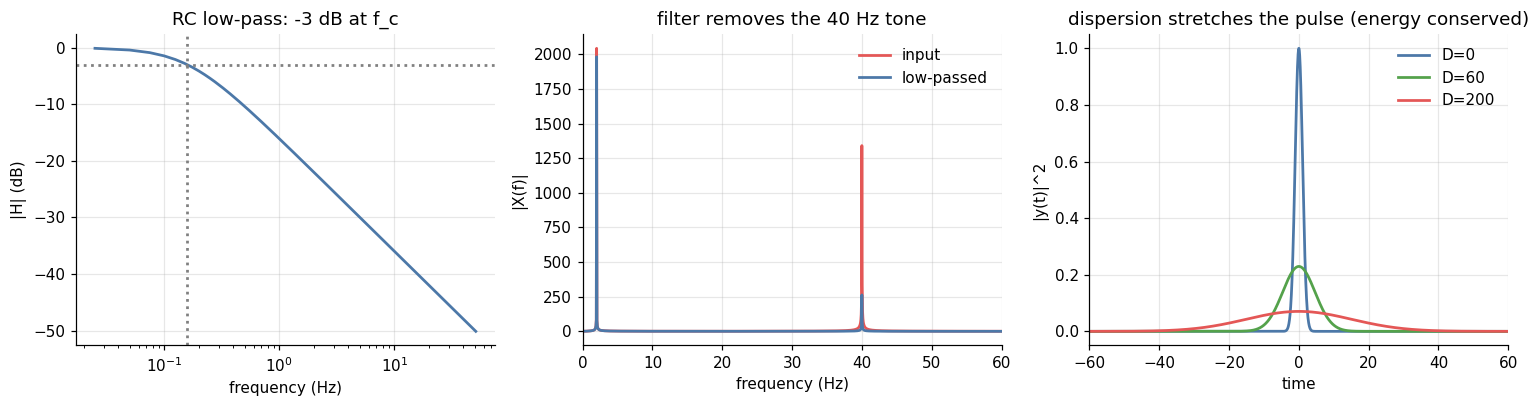

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
# RC low-pass frequency response
f = np.fft.rfftfreq(4096, d=40.0/4096)
H = 1/(1 + 1j*2*np.pi*f*1.0)
ax[0].semilogx(f[1:], 20*np.log10(np.abs(H[1:])), color="#4C78A8")
ax[0].axvline(1/(2*np.pi), ls=":", color="gray"); ax[0].axhline(-3, ls=":", color="gray")
ax[0].set_xlabel("frequency (Hz)"); ax[0].set_ylabel("|H| (dB)")
ax[0].set_title("RC low-pass: -3 dB at f_c")
# filtering: spectrum before/after
N=4096; fs=200.0; tg=np.arange(N)/fs
x = np.sin(2*np.pi*2*tg)+0.7*np.sin(2*np.pi*40*tg)
fr = np.fft.rfftfreq(N, d=1/fs); Hf = 1/(1+1j*2*np.pi*fr*(1/(2*np.pi*8)))
y = np.fft.irfft(np.fft.rfft(x)*Hf, n=N)
ax[1].plot(fr, np.abs(np.fft.rfft(x)), color="#E45756", label="input")
ax[1].plot(fr, np.abs(np.fft.rfft(y)), color="#4C78A8", label="low-passed")
ax[1].set_xlim(0, 60); ax[1].set_xlabel("frequency (Hz)"); ax[1].set_ylabel("|X(f)|")
ax[1].set_title("filter removes the 40 Hz tone"); ax[1].legend()
# time-stretch: a pulse broadening with dispersion
Nt=8192; Tt=200.0; dt=Tt/Nt; tt=(np.arange(Nt)-Nt//2)*dt; ff=np.fft.fftfreq(Nt, d=dt)
xp = np.exp(-tt**2/(2*1.5**2)).astype(complex)
for D,c in [(0.0,"#4C78A8"),(60.0,"#54A24B"),(200.0,"#E45756")]:
    yp = np.fft.ifft(np.fft.fft(xp)*np.exp(1j*np.pi*D*ff**2))
    ax[2].plot(tt, np.abs(yp)**2, color=c, label=f"D={D:.0f}")
ax[2].set_xlim(-60, 60); ax[2].set_xlabel("time"); ax[2].set_ylabel("|y(t)|^2")
ax[2].set_title("dispersion stretches the pulse (energy conserved)"); ax[2].legend()
plt.tight_layout(); plt.show()

## Summary

- An LTI system is one signal, the **impulse response** $h(t)$: $y=x*h$, and $Y(f)=X(f)H(f)$.
- The **Dirac delta** is the convolution identity (sifting $\int\delta(t-a)f\,dt=f(a)$); a numerical
  delta is a unit-area pulse taken narrow.
- A **filter** shapes $|H(f)|$: the RC low-pass has $H=1/(1+j2\pi fRC)$, $-3\ \mathrm{dB}$ at
  $f_c=1/(2\pi RC)$, and removes tones above the corner.
- **Time-stretch/dispersion** is the all-pass $H=e^{\,j\pi Df^2}$: magnitude one (spectrum and energy
  preserved), quadratic phase, linear group delay $-Df$ -- the frequency-to-time map at the heart of
  the dispersive Fourier transform.

Subject-verb-object: the delta probes the system; the impulse response defines it; convolution
produces the output; the transfer function filters the spectrum; dispersion stretches the pulse. This
is the signals-and-systems language every later instrument chapter speaks.